<a href="https://colab.research.google.com/github/Sharath0Kumar/aiml_lab/blob/main/BreastCancerModelTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix


data = pd.read_csv("data.csv")

print(data.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [4]:
print("Dataset shape :" , data.shape)


Dataset shape : (569, 33)


In [5]:
print("Columns :")
print(data.columns.tolist())

Columns :
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [6]:
print("Summary :")
print(data.describe())

Summary :
                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.0

In [7]:
misssing = data.isnull().sum()

print("Misssing Values :")
print(misssing)

Misssing Values :
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_wor

In [8]:
data = data.drop(
    columns=["id", "Unnamed: 32"],
    errors="ignore"
)

In [9]:
misssing = data.isnull().sum()

print("Misssing Values :")
print(misssing)

Misssing Values :
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [10]:
print(data.head())

print(data.shape)

  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          17.33 

In [11]:
data["diagnosis"] = data["diagnosis"].map({"M" : 1 , "B" : 0})

In [12]:
print(data["diagnosis"].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [13]:
print(data["diagnosis"].head(10))

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: diagnosis, dtype: int64


In [14]:
x = data.drop("diagnosis", axis = 1)
y = data["diagnosis"]

print(x.head())
print(x.shape)

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

In [15]:
print(y.head())

print(y.shape)

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64
(569,)


In [16]:
scaler = StandardScaler()
x_scaler = scaler.fit_transform(x)

In [17]:
print(x_scaler[:5])

print(x_scaler.shape)

[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.43889668e-01  2.81189987e-01]
 [ 1.5

In [18]:
x_train , x_test , y_train , y_test = train_test_split(x_scaler , y , test_size = 0.30 ,random_state = 42)

In [19]:
print(x_train.shape)

print(x_test.shape)

print(y_train.shape)

print(y_test.shape)

(398, 30)
(171, 30)
(398,)
(171,)


In [20]:
dt = DecisionTreeClassifier(random_state =42)

dt.fit(x_train , y_train)

print("Decision Tree Training Completed!!!")

Decision Tree Training Completed!!!


In [21]:
print("Training Accuracy :")
print(dt.score(x_train , y_train))

Training Accuracy :
1.0


In [22]:
dt_pred = dt.predict(x_test)

print("Acutal values    :" , y_test.values[:20])

print("Predicted values :" , dt_pred[:20])

Acutal values    : [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1]
Predicted values : [0 1 1 0 0 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1]


In [23]:
dt_accuracy = accuracy_score(y_test , dt_pred)
dt_precision = precision_score(y_test , dt_pred)
dt_recall = recall_score(y_test , dt_pred)
dt_f1 = f1_score(y_test , dt_pred)


print("Acurracy : " , dt_accuracy)
print("Precision : " , dt_precision)
print("Recall : " , dt_recall)
print("F1 Score : " , dt_f1)


Acurracy :  0.9415204678362573
Precision :  0.8955223880597015
Recall :  0.9523809523809523
F1 Score :  0.9230769230769231


In [24]:
print("Confusion Matrix :")

dt_cm = confusion_matrix(y_test , dt_pred)
print(dt_cm)

Confusion Matrix :
[[101   7]
 [  3  60]]


In [25]:
lr = LogisticRegression(max_iter =1000)

lr.fit(x_train , y_train)

print("Logistic Training Completed !!")


Logistic Training Completed !!


In [26]:
lr_pred = lr.predict(x_test)

print("Acutual Values  : " , y_test.values[:20])
print("Predicted Values: " , lr_pred[:20])

Acutual Values  :  [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1]
Predicted Values:  [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1]


In [27]:
lr_accuracy = accuracy_score(y_test , lr_pred)

lr_precision = precision_score(y_test , lr_pred)

lr_recall = recall_score(y_test , lr_pred)

lr_f1 = f1_score(y_test , lr_pred)

lr_cm = confusion_matrix(y_test ,lr_pred)

In [28]:
print("Acurracy :" , lr_accuracy)
print("Precision :" , lr_precision)
print("Recall :" , lr_recall)
print("F1 Score :" , lr_f1)

print("Confusion Matrix :")
print(lr_cm)

Acurracy : 0.9824561403508771
Precision : 0.96875
Recall : 0.9841269841269841
F1 Score : 0.9763779527559056
Confusion Matrix :
[[106   2]
 [  1  62]]


In [29]:
print("\n\t========== FINAL COMPARISON ==========")

print("\n\tDecision Tree\tLogistic Regression")

print("Accuracy  :", round(dt_accuracy, 4),"\t", round(lr_accuracy, 4))

print("Precision :", round(dt_precision, 4),"\t", round(lr_precision, 4))

print("Recall    :", round(dt_recall, 4),"\t", round(lr_recall, 4))

print("F1 Score  :", round(dt_f1, 4),"\t", round(lr_f1, 4))



	========== FINAL COMPARISON ==========

	Decision Tree	Logistic Regression
Accuracy  : 0.9415 	 0.9825
Precision : 0.8955 	 0.9688
Recall    : 0.9524 	 0.9841
F1 Score  : 0.9231 	 0.9764


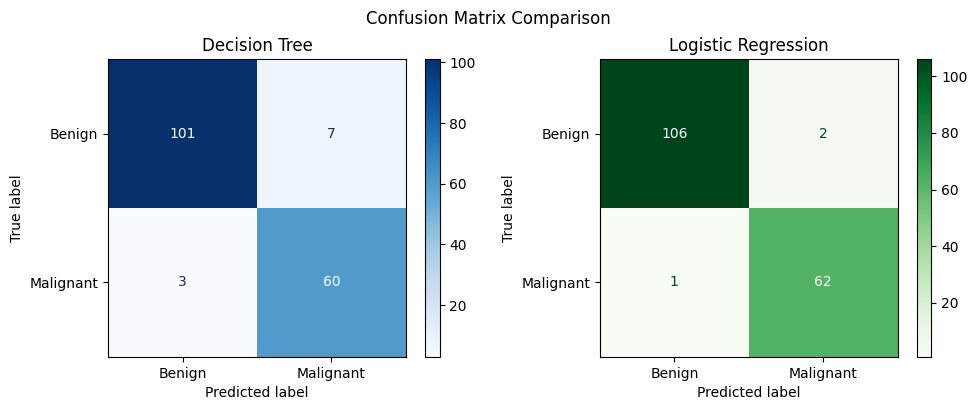

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["Benign", "Malignant"]
).plot(ax=axes[0], cmap="Blues")

axes[0].set_title("Decision Tree")


ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["Benign", "Malignant"]
).plot(ax=axes[1], cmap="Greens")

axes[1].set_title("Logistic Regression")


plt.suptitle("Confusion Matrix Comparison")

plt.tight_layout()

plt.show()

In [31]:
print("\n========== CONCLUSION ==========")

if dt_f1 > lr_f1:
    print("Decision Tree is the better model.")
else:
    print("Logistic Regression is the better model.")


========== CONCLUSION ==========
Logistic Regression is the better model.
